# Diseñar una capa entrenable que represente un polinomio grado 3: 
# $f (x) = a_0 + a_1x + a_2x^2 + a_3x^3$ .
# Los parámetros entrenables son los coefientes $a_0$ , $a_1$ , $a_2$ , $a_3$ . Posteriormente, entrenarla para ajustarla a la función $f(x) = cos(2x)$ en el intervalo [-1,1].

In [1]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, metrics, Sequential
from tensorflow.keras.layers import Dense
import matplotlib.pyplot as plt
from keras.optimizers import Adam
import numpy as np

2026-09-20 19:54:31.432666: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-09-20 19:54:31.443797: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1789955671.453866 3195512 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1789955671.457172 3195512 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2026-09-20 19:54:31.470347: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instr

In [2]:
class CapaPolinomio(layers.Layer):
    def __init__(self, **kwargs):
        super().__init__(**kwargs)

    def build(self, input_shape):

        self.w = self.add_weight(
            name="coeficientes_polinomio",
            shape=(4,),
            initializer="random_normal",
            trainable=True,
            dtype=tf.float32
        )
        super().build(input_shape)

    def call(self, inputs):
        """La salida de la red es la aprox del polinomio"""
        x = inputs
        poli = self.w[0] + self.w[1] * x + self.w[2] * (x ** 2) + self.w[3] * (x ** 3)
        return poli

    def get_config(self):
        return super().get_config()

## Reusamos la clase ModeloFunción del inciso 2 para ajustar a la función $cos(2x)$

In [3]:
class ModeloFuncion(Sequential):
    def __init__(self,layers=None, name=None):
        super().__init__(layers=layers, name=name)
        self.loss_tracker = metrics.Mean(name="loss")

    @property
    def metrics(self):
        return [self.loss_tracker]

    def train_step(self, data):
        """La forma de y debe de tener la forma de la función objetivo"""
        x, y = data

        with tf.GradientTape() as tape:
            y_pred = self(x, training=True)
            loss = tf.reduce_mean(tf.square(y_pred - y))

        grads = tape.gradient(loss, self.trainable_weights)
        self.optimizer.apply_gradients(zip(grads, self.trainable_weights))
        self.loss_tracker.update_state(loss)
        return {"loss": self.loss_tracker.result()}

## Ajuste de la función $cos(2x)$ con la capa Polinomio

In [4]:
model = ModeloFuncion()
model.add(CapaPolinomio(input_shape=(1,)))
model.summary()

I0000 00:00:1789955673.404499 3195512 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 1194 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 4060 Laptop GPU, pci bus id: 0000:01:00.0, compute capability: 8.9
/tmp/ipykernel_3195512/2036649374.py:3: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "modelo_funcion"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ capa_polinomio (CapaPolinomio)  │ (None, 1)              │             4 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4 (16.00 B)

 Trainable params: 4 (16.00 B)

 Non-trainable params: 0 (0.00 B)

In [5]:
num_muestras = 1000
x = tf.random.uniform((num_muestras,1), minval=-1, maxval=1)
y = tf.math.cos(2*x) #Funcion objetivo
model.compile(optimizer=Adam(learning_rate=0.001), metrics=['loss'])
history = model.fit(x=x,y=y,epochs=1000,verbose=0,batch_size=64)

I0000 00:00:1789955674.175089 3516397 service.cc:148] XLA service 0x7f7a10102040 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1789955674.175108 3516397 service.cc:156]   StreamExecutor device (0): NVIDIA GeForce RTX 4060 Laptop GPU, Compute Capability 8.9
2026-09-20 19:54:34.182525: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:268] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
I0000 00:00:1789955674.201985 3516397 cuda_dnn.cc:529] Loaded cuDNN version 90300
I0000 00:00:1789955674.295138 3516397 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


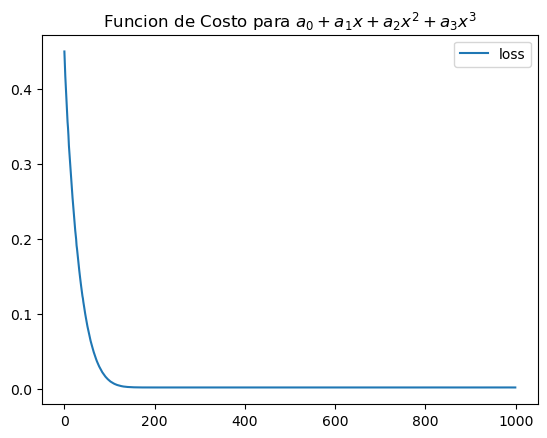

In [6]:
plt.plot(history.history["loss"], label='loss')
plt.title(r"Funcion de Costo para $a_0 + a_1x + a_2x^2 + a_3x^3$")
plt.legend()
plt.show()

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step


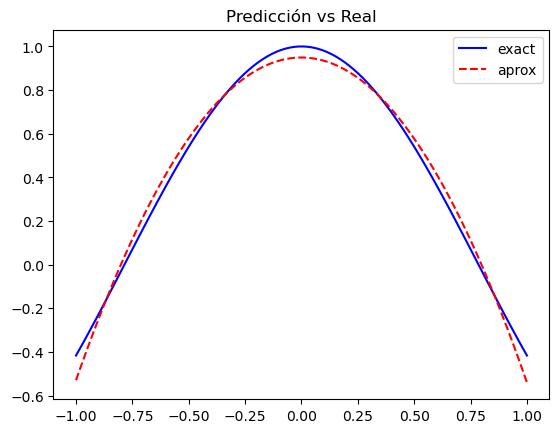

In [7]:
x=tf.linspace(-1,1,100)
y_pred=model.predict(x)
plt.plot(x, np.cos(2*x), label="exact", color='blue')
plt.plot(x,y_pred,label="aprox", color='red', linestyle='--')
plt.title("Predicción vs Real")
plt.legend()
plt.show()